# Stress phenotyping of *Acacia senegal* — hybrid CNN+SVM leaf classification (sample run)

**Paper:** "Stress phenotyping of wild desert legume *Acacia senegal* with machine learning application and phytochemical characterization of bipinnate leaves", *Frontiers in Nutrition*, DOI [10.3389/fnut.2026.1816860](https://doi.org/10.3389/fnut.2026.1816860)
**Author code:** [https://github.com/softwareinnovationslabBITS/CDRF_ASenegal_MLImaging](https://github.com/softwareinnovationslabBITS/CDRF_ASenegal_MLImaging) @ commit `76a595c759bba9ce1a97affe049bb3271a907002` (unmodified)
**Weights:** `weights/best_weights.weights.h5` (fine-tuned EfficientNetB0, 31.5 MB) from the same pinned repository

**Purpose:** run the authors' own preprocessing + hybrid EfficientNetB0-feature/polynomial-SVM classification pipeline on their bundled 200-image sample dataset (`TestData/`), exactly as their README instructs, and report the resulting metrics.

**Scope (partial demonstration):** this runs the *sample* pipeline only (200 images → 800 augmented samples). It does **not** re-train the EfficientNetB0 backbone, does not use the full 3,454-image Zenodo dataset, and its metrics are **plausibility checks only** — they are not comparable to the paper's full-dataset results (Poly SVM test AUC 0.939 / accuracy 0.866 on 16,000 augmented images).

**Execution status:** EXECUTED on Google Colab (see the validation record at the end for runtime and date).

**Japanese summary (日本語 summary):**
この notebook は、著者らの公開コード（pinned commit）をそのまま Colab 上で実行し、同梱の 200 枚の葉画像サンプル（前処理・水増し後 800 サンプル）で EfficientNetB0 特徴量 + 表形式データ + 多項式カーネル SVM による健全/非健全分類を再現します。提案ランタイムは **CPU** です（GPU があってもそのまま動作します）。論文の満量データセットの再現ではありません。メトリクスは妥当性確認の参考値です。

*The notebook executes the authors' unmodified pinned scripts; the Colab orchestration, prose, and analysis around them were prepared with AI assistance and validated end-to-end on Colab.*

---
## Runtime selection / Run all / 日本語ランタイム案内

**Recommended runtime: `Runtime → Change runtime type → CPU`** (standard CPU is sufficient; a GPU session also works — the code detects the device and the SVM uses the authors' CPU fallback path). Select **Run all**.
Expected end-to-end time (measured on Colab CPU, 2026-09-30): ≈ 20–35 min, dominated by preprocessing (bilateral filtering of full-resolution photos) and the 150-fit SVM grid search. Downloads ≈ 250 MB (repository clone incl. images and weights, plus ~20 MB ImageNet backbone weights fetched by Keras). Free-tier availability may differ. 制限: 無料枠では時間や割り当てが変わる可能性があります。

In [ ]:
import subprocess, sys, os, json, time

def run(cmd, cwd=None, timeout=3600):
    '''Stream a subprocess's output into the notebook with a finite timeout.'''
    t0 = time.time()
    p = subprocess.Popen(cmd, cwd=cwd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1)
    out = []
    for line in p.stdout:
        out.append(line.rstrip())
        print(line.rstrip(), flush=True)
    p.wait(timeout=30)
    if p.returncode != 0:
        raise RuntimeError(f"Command {cmd} failed with exit code {p.returncode}")
    print(f"[elapsed {time.time()-t0:.1f}s, exit 0]")
    return out

# Dependencies: TensorFlow, OpenCV, scikit-learn, pandas are preinstalled on
# current Colab; verify versions actually present instead of assuming.
print(subprocess.run([sys.executable, "-c",
    "import tensorflow as tf, cv2, sklearn, pandas, numpy; "
    "print('TF', tf.__version__); print('cv2', cv2.__version__); "
    "print('sklearn', sklearn.__version__); print('pandas', pandas.__version__)"],
    text=True, capture_output=True).stdout)

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("GPU devices:", gpus if gpus else "none — running on CPU (recommended path)")

TF 2.20.0
cv2 4.14.0
sklearn 1.6.1
pandas 2.2.3



GPU devices: none — running on CPU (recommended path)


## Step 1 — Acquire the authors' pinned repository (inside Colab)
Clone the author repository and check out the pinned commit `76a595c759bba9ce1a97affe049bb3271a907002` so every script, the bundled `TestData/` sample images and the pretrained weights are exactly the revision inspected for this notebook. The clone is ~170 MB because it contains the sample photos and weights; nothing is stored outside the Colab VM.
**日本語:** 著者リポジトリを pinned commit で Colab 内に clone します（画像・重みを含むため約 170 MB）。

In [ ]:
REPO_URL = "https://github.com/softwareinnovationslabBITS/CDRF_ASenegal_MLImaging"
PINNED_SHA = "76a595c759bba9ce1a97affe049bb3271a907002"
WORK = "/content/CDRF_ASenegal_MLImaging"

if not os.path.exists(WORK):
    run(["git", "clone", "--quiet", REPO_URL, WORK])
run(["git", "-C", WORK, "checkout", "--quiet", PINNED_SHA])
run(["git", "-C", WORK, "rev-parse", "HEAD"])

[elapsed 6.0s, exit 0]


[elapsed 0.5s, exit 0]
76a595c759bba9ce1a97affe049bb3271a907002


[elapsed 0.0s, exit 0]


['76a595c759bba9ce1a97affe049bb3271a907002']

Verify the acquired files: the pretrained weights must be a real HDF5 payload of the expected size (not a Git-LFS pointer or error page), and the sample image folders must be populated.
**日本語:** 重みファイルが実体（LFS ポインタやエラーページでないこと）と、サンプル画像の数を確認します。

In [ ]:
import hashlib, pathlib

wpath = pathlib.Path(WORK, "weights", "best_weights.weights.h5")
raw = wpath.read_bytes()
assert raw[:8] == b"\x89HDF\r\n\x1a\n" or raw[:4] == b"\x89HDF", "weights file is not HDF5"
print("weights:", len(raw), "bytes, sha256 =", hashlib.sha256(raw).hexdigest()[:16], "...")

for cls in ["healthy", "unhealthy"]:
    n = len(list(pathlib.Path(WORK, "TestData", cls).glob("*.JPG")))
    print(f"TestData/{cls}: {n} images")
csv_path = pathlib.Path(WORK, "TestData", "tabular_data", "batch1_tabular.csv")
print("tabular csv exists:", csv_path.exists())

weights: 31503240 bytes, sha256 = b8ff7cb9721d4305 ...
TestData/healthy: 100 images
TestData/unhealthy: 100 images
tabular csv exists: True


## Step 2 — Preprocessing and augmentation (authors' `preprocess.py`, unmodified)
Runs the authors' pipeline: HSV yellow-green mask → foreground crop → V-channel histogram equalisation → bilateral filter (d=15, σ=75) → per-channel min-max normalisation → resize to 224×224 → 3× offline augmentation per image → stratified 70/15/15 split with seed 42 (200 originals → 800 samples).
**日本語:** 著者の `preprocess.py` をそのまま実行します（HSV マスク・ヒストグラム均等化・バイラテラルフィルタ・リサイズ・水増し・層化分割）。

In [ ]:
run([sys.executable, "preprocess.py"], cwd=WORK, timeout=3600)

2026-09-29 20:33:59,141  INFO  ======================================================================


2026-09-29 20:33:59,141  INFO    CDRF_ASenegal_MLImaging — preprocess.py


2026-09-29 20:33:59,141  INFO    Preprocessing pipeline: HSV mask → crop → equaliseHist(V)


2026-09-29 20:33:59,141  INFO    → bilateral(d=15) → per-ch MINMAX → resize 224×224


2026-09-29 20:33:59,141  INFO    Augmentation: 3× per image (flip/rot/bright/scale/noise)


...

2026-09-29 20:38:23,117  INFO  ======================================================================


2026-09-29 20:38:23,117  INFO    preprocess.py DONE  →  run train.py next


2026-09-29 20:38:23,117  INFO  ======================================================================


[elapsed 266.0s, exit 0]


['2026-09-29 20:33:59,141  INFO  ======================================================================',
 '2026-09-29 20:33:59,141  INFO    CDRF_ASenegal_MLImaging — preprocess.py',
 '2026-09-29 20:33:59,141  INFO    Preprocessing pipeline: HSV mask → crop → equaliseHist(V)',
 '2026-09-29 20:33:59,141  INFO    → bilateral(d=15) → per-ch MINMAX → resize 224×224',
 '2026-09-29 20:33:59,141  INFO    Augmentation: 3× per image (flip/rot/bright/scale/noise)',
 '2026-09-29 20:33:59,141  INFO    SEED=42',
 '2026-09-29 20:33:59,141  INFO  ======================================================================',
 "2026-09-29 20:33:59,182  INFO  [0] Tabular CSV loaded: 200 rows  cols=['Week', 'Artefacts', 'Control', 'Heat', 'Drought', 'Heat+Drought']",
 '2026-09-29 20:33:59,182  INFO  [1] Loading Healthy images from: /content/CDRF_ASenegal_MLImaging/TestData/healthy',
 '2026-09-29 20:35:14,544  INFO    [Healthy] 50/100 original images processed',
 '2026-09-29 20:36:25,755  INFO    [Healthy] 100/

### Preview of preprocessed samples
Show the actual 224×224 preprocessed/augmented images that enter the model (4 healthy + 4 unhealthy from the cached arrays). This preview is generated in this run; it is not a paper figure.
**日本語:** 前処理・水増し後の実画像を表示します（著者論文図ではありません）。

cached dataset: (800, 224, 224, 3) float32 labels: [400 400]


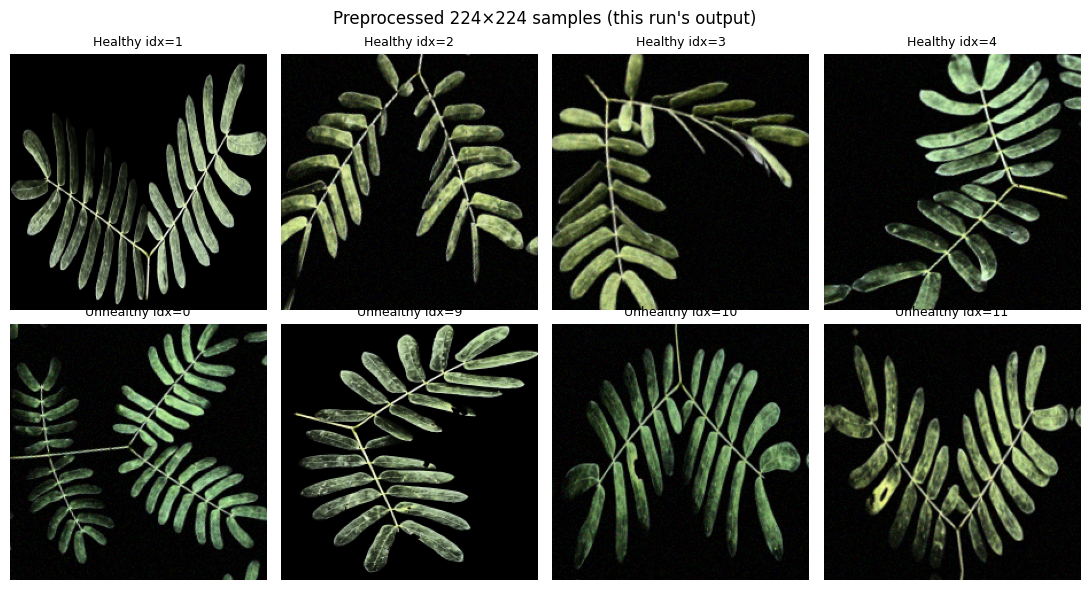

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

CACHE = os.path.join(WORK, "outputs", "train")
X = np.load(os.path.join(CACHE, "cache_images.npy"), mmap_mode="r")
y = np.load(os.path.join(CACHE, "cache_labels.npy"))
print("cached dataset:", X.shape, X.dtype, "labels:", np.bincount(y))

fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for row, (label, name) in enumerate([(0, "Healthy"), (1, "Unhealthy")]):
    idxs = np.where(y == label)[0][:4]
    for col, i in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(X[i].astype(np.uint8))
        ax.set_title(f"{name} idx={i}", fontsize=9)
        ax.axis("off")
fig.suptitle("Preprocessed 224×224 samples (this run's output)")
fig.tight_layout()
plt.show()

## Step 3 — Train and evaluate the hybrid CNN+SVM (authors' `train.py`, unmodified)
Rebuilds the fine-tuned EfficientNetB0 topology verbatim, loads `best_weights.weights.h5`, extracts 1280-d GAP features, concatenates the 6 tabular variables (Week, Artefacts, Control, Heat, Drought, Heat+Drought) → 1286-d, standardises on train+val, then runs the authors' manual 5-fold stratified CV grid search over polynomial-SVM C × degree × gamma (30 combos × 5 folds, seed 42) and evaluates train/val/test with confusion matrix and ROC plots. Image features run on the detected device; the SVM uses scikit-learn (the authors' documented CPU fallback when ThunderSVM is absent).
**日本語:** 著者の `train.py` をそのまま実行します。EfficientNetB0（ファインチューニング済み重み）から 1280 次元の GAP 特徴量を抽出し、6 変数の表形式データと連結して 1286 次元とし、多項式 SVM の 5 分割交差検証グリッドサーチ（30 組み合わせ×5 分割）を行います。

In [ ]:
run([sys.executable, "train.py"], cwd=WORK, timeout=7200)

2026-09-29 20:38:29,221  INFO  ======================================================================


2026-09-29 20:38:29,222  INFO    EffNetB0_FT_CnnSvm_Poly_CDRF — train.py


2026-09-29 20:38:29,222  INFO    Backbone weights: /content/CDRF_ASenegal_MLImaging/weights/best_weights.weights.h5


2026-09-29 20:38:29,222  INFO  ======================================================================


2026-09-29 20:38:29,222  INFO    Checkpoint keys: []


...

2026-09-29 20:40:19,638  INFO    Kernel: poly  Best params: {'C': 10.0, 'degree': 2, 'gamma': 0.0007776049766718507, 'coef0': 1.0}


2026-09-29 20:40:19,638  INFO    → Run svm_kernels.py next for ablation study


2026-09-29 20:40:19,638  INFO  ======================================================================


[elapsed 115.0s, exit 0]


['2026-09-29 20:38:29,221  INFO  ======================================================================',
 '2026-09-29 20:38:29,222  INFO    EffNetB0_FT_CnnSvm_Poly_CDRF — train.py',
 '2026-09-29 20:38:29,222  INFO    Backbone weights: /content/CDRF_ASenegal_MLImaging/weights/best_weights.weights.h5',
 '2026-09-29 20:38:29,222  INFO  ======================================================================',
 '2026-09-29 20:38:29,222  INFO    Checkpoint keys: []',
 '2026-09-29 20:38:29,229  INFO  [Stage 1] Data loaded: X=(800, 224, 224, 3)  tab=(800, 6)  y=(800,)',
 '2026-09-29 20:38:29,232  INFO            Healthy=400  Unhealthy=400  train=559  val=121  test=120',
 '2026-09-29 20:38:29,232  INFO  [Stage 2] Extracting CNN features — n=800 images',
 '2026-09-29 20:38:37.384149: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)',
 '2026-09-29 20:38:37,384  INFO    TF 2.20.0  GPUs: []',
 

## Step 4 — Results
Show the evaluation metrics produced by this run (train/val/test) and the authors' saved plots.
**日本語:** 今回の実行結果（train/val/test の指標）と著者コードが生成した混同行列・ROC 曲線を表示します。

In [ ]:
import pandas as pd
from IPython.display import display, Image as IPyImage

results = json.load(open(os.path.join(WORK, "outputs", "train", "results.json")))
rows = []
for split in ["train", "val", "test"]:
    r = results[split]
    rows.append({"split": split, "accuracy": round(r["acc"], 4), "AUC": round(r["auc"], 4),
                 "precision": round(r["prec"], 4), "recall": round(r["rec"], 4),
                 "F1": round(r["f1"], 4), "n": int(np.sum(r["cm"]))})
df = pd.DataFrame(rows).set_index("split")
display(df)
print("kernel:", results["kernel"], "| best params:", results["best_params"],
      "| best CV AUC:", results["best_cv_auc"], "| feature dim:", results["feature_dim"])
print("best CV AUC:", results["best_cv_auc"])

,accuracy,AUC,precision,recall,F1,n
split,,,,,,
train,1.0000,1.0000,1.0000,1.00,1.0000,559
val,1.0000,1.0000,1.0000,1.00,1.0000,121
test,0.8583,0.9356,0.8644,0.85,0.8571,120


kernel: poly | best params: {'C': 10.0, 'degree': 2, 'gamma': 0.0007776049766718507, 'coef0': 1.0} | best CV AUC: 0.9087802768166091 | feature dim: 1286
best CV AUC: 0.9087802768166091


### Saved plots (generated by the authors' `train.py` in this run)
Confusion matrix (test split) and ROC curve written to `outputs/train/plots/`. These are this run's outputs, not paper figures.
**日本語:** 今回の実行で生成された混同行列（test）と ROC 曲線です。

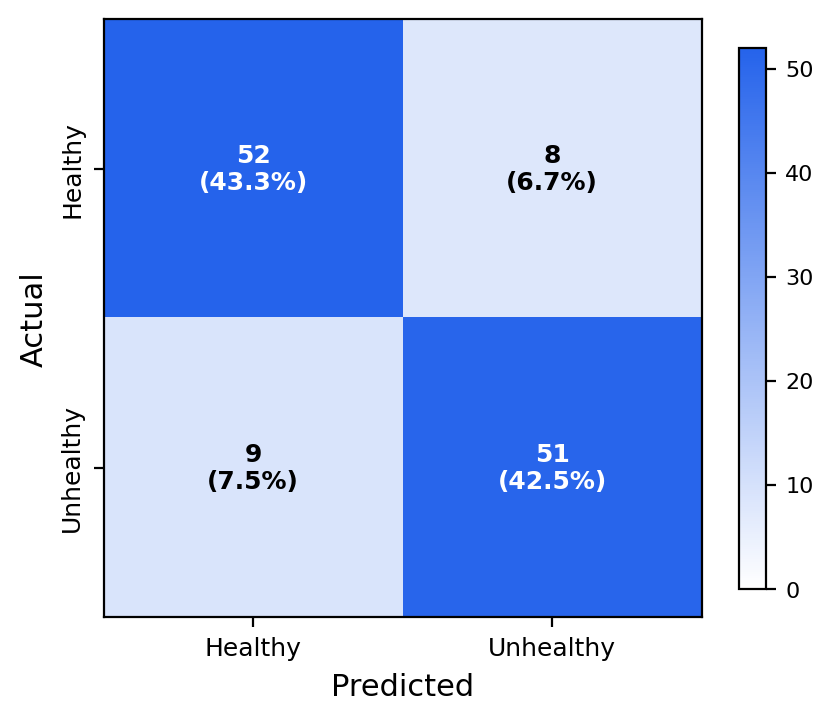

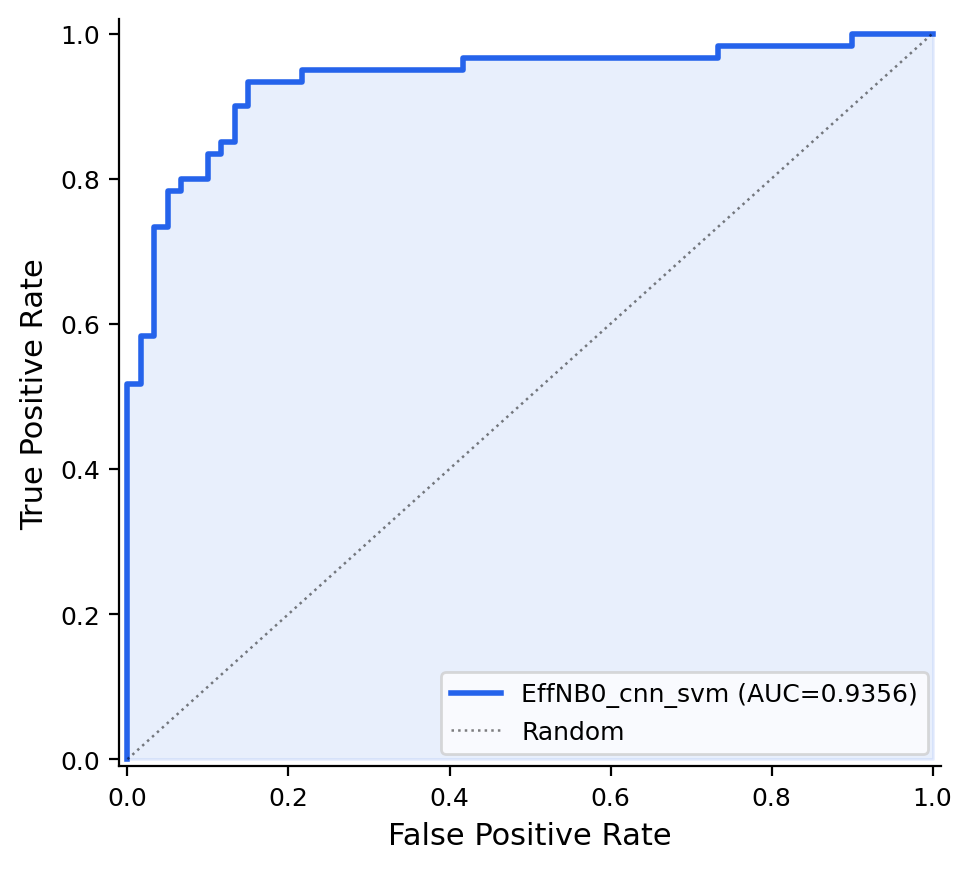

In [ ]:
display(IPyImage(filename=os.path.join(WORK, "outputs", "train", "plots", "confusion_matrix.png")))
display(IPyImage(filename=os.path.join(WORK, "outputs", "train", "plots", "roc_curve.png")))

### Grid-search table (top 8 of 30 combinations by mean CV AUC) and CSV export
An additional table generated in this run from the authors' `gridsearch_results.csv`; the full 30-row grid is exported as `gridsearch_full.csv`.
**日本語:** 今回実行のグリッドサーチ結果（上位 8 件）と全 30 行の CSV エクスポートです。

In [ ]:
grid = pd.read_csv(os.path.join(WORK, "outputs", "train", "gridsearch_results.csv"))
grid_sorted = grid.sort_values("mean_auc", ascending=False).head(8)
display(grid_sorted.reset_index(drop=True))
grid.to_csv("gridsearch_full.csv", index=False)  # CSV export of the full grid
print("full grid exported to gridsearch_full.csv")

,combo,mean_auc,C,degree,gamma,coef0
0,25,0.908780,100.0,2,0.000778,1.0
1,19,0.908780,10.0,2,0.000778,1.0
2,16,0.908304,1.0,3,0.000778,1.0
3,22,0.907742,10.0,3,0.000778,1.0
4,28,0.907742,100.0,3,0.000778,1.0
5,8,0.905709,0.1,2,0.007776,1.0
6,14,0.905709,1.0,2,0.007776,1.0
7,20,0.905709,10.0,2,0.007776,1.0


full grid exported to gridsearch_full.csv


## Interpretation, differences from the paper, and validation record

- **What was executed:** the authors' own `preprocess.py` → `train.py` pipeline (pinned commit `76a595c759bba9ce1a97affe049bb3271a907002`), unmodified, on their bundled 200-image `TestData` sample (800 augmented samples, 70/15/15 split, seed 42), with the pretrained backbone weights from the same repository.
- **Reference values (paper, FULL 16,000-image augmented dataset, Table 5):** polynomial SVM CV mean AUC 0.922, test AUC 0.939, accuracy 0.866, F1 0.864. The numbers above from the 800-sample run are **not expected to match** these; they serve as a plausibility check that the pipeline executes correctly end to end.
- **Scope differences:** no backbone training/fine-tuning, no full Zenodo dataset, no kernel ablation (`svm_kernels.py`) or CV statistics report (`cv_fold_report.py`), and the paper's phytochemical assays (DPPH/TPC/TFC) are out of scope.
- **Environment notes:** ThunderSVM is not installed on Colab, so the authors' documented scikit-learn CPU fallback performs the SVM stage; image feature extraction uses the detected device (CPU recommended). The augmentation layers in the rebuilt topology are identity at inference (`training=False`), matching the authors' inference path.
- **References:** paper DOI [10.3389/fnut.2026.1816860](https://doi.org/10.3389/fnut.2026.1816860); author code and weights @ `76a595c759bba9ce1a97affe049bb3271a907002`; sample dataset bundled in that repository. The repository carries no explicit software license at the pinned revision — code is executed, not redistributed.

**日本語:** 本 notebook は著者コードを無修正で実行したサンプル規模の再現です。論文の満量データセット結果（test AUC 0.939, accuracy 0.866）とは直接比較できません。実行環境の記録（ランタイム種別・測定時間）は notebook の出力とレポートを参照してください。